# Traditional evaluation pipeline

This notebook explores conduct traditional evaluation pipeline: train and evaluate on the same token networks. In particular, this notebook answer the following research questions:

I. How do traditional machine learning models such as Logistic Regression, Random Forest, Gradient Boosting (GBM), SVM and KNN perform in predicting whether the `close price` of a token increase/decrease in the next day (binary classification)? What is the importance of each feature contributing to the prediction?

II. How do traditional machine learning models such as Linear Regression, Ridge, Lasso, Random Forest (regression version), GBM and SVR perform in predicting `close price` of a token in the following day (regression)? What is the importance of each feature contributing to the prediction?

III. Can time-series model such as ARIMA performs better in regression task?

## 1. Set up

We first set up the environment for experiment. This step include

1. Import all dependencies
2. Declare global environment to config the experiment
3. Declare all support functions needed for the experiment

### 1. Import all dependencies

This experiment requires the following libraries to run
- torch
- sklearn
- numpy
- pmdarima
- seaborn
- matplotlib

*If your virtual environment is missing any of these library, you need to run `pip install` to install missing libraries*

In [2]:
from src.data import Dataloader
import pandas as pd
import os
from src.utils import seed_everything
import random
from tqdm import tqdm
from typing import Callable
import torch.nn.functional as F
from src.data import TimeSeriesDataset
import torch
from sklearn.metrics import roc_auc_score
import warnings
from sklearn.exceptions import DataConversionWarning

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_percentage_error
import numpy as np
import copy

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import roc_auc_score
import warnings

import pmdarima as pm
from typing import Tuple

import seaborn as sns
import matplotlib.pyplot as plt


### 1.2 Declare global environment to config the experiment

This section below will set up constant needed for experiment

**Important: To save time, we load the results (if they have been already generated by previous run). If you want to regenerate the results, please set `RE_RUN_EVERYTHING` to `False`**

In [3]:
# Clean data location
DATA_PATH = os.path.abspath('data/clean/')

# Path to where we cache the result
RESULT_PATH = os.path.abspath('data/results/')

# Train, validation and test split
TRAIN_RATIO = 0.7
VAL_RATIO = 0.15
TEST_RATIO = 0.15  

# Columns that are used as features for training
ALL_FEAT_COLUMN = ['Close','High','Low', 'Open','Volume','sentiment_score_mean','sentiment_polarity_mean','sentiment_subjectivity_mean','news_count', 'log_return', 'vol_7d','vol_30d','ma_7','ma_30','ma_ratio']

# Columns that are used as features for training but do NOT need to normalize
ALREADY_NORMALIZE_FEAT = ['sentiment_score_mean','sentiment_polarity_mean','sentiment_subjectivity_mean','news_count','ma_ratio','log_return']

# Label for binary classification task
BINARY_LABEL_COLUMN = 'price_increase'

# Label for regression task
REGRESSION_LABEL_COLUMN = 'next_close'

# Number of tokens used in training to demonstrate scaling laws
LOG_SCALING = [2,4,8,16,32]

# For reproducibility, inital random seed
INIT_SEED = 720

# Force re-run. To save time, we load the results (if they have been already generated by previous run.
# If the results have not yet computed or `RE_RUN_EVERYTHING` is set to True, the following script re-generate everything
RE_RUN_EVERYTHING = False

seed_everything(INIT_SEED)

files = os.listdir(DATA_PATH)


### 1.3. Declare all support functions needed for the experiment

To conduct experiment, we define the following support functions

1. `normalize`: normalize continuous features for training

In [4]:
def normalize(train_data: TimeSeriesDataset, valid_data: TimeSeriesDataset, test_data: TimeSeriesDataset, normalize_y = False, exclude_cols = []):
    r"""
    Normalize each feature in training, validation and testing data with max and min of the feature from training data.

    Args:
    - `train_data` (TimeSeriesDataset): data split for training
    - `valid_data` (TimeSeriesDataset): data split for validation
    - `test_data` (TimeSeriesDataset): data split for testing
    - `normalize_y` (bool): whether to normalize input (True for regresison case and False for binary classification case)
    - `exclude_cols` (list): columns that don't need to normalize

    Return:
    - data splits for training, validation and testing with normalized features
    """
    n_cols = train_data.x.shape[1]
    include_cols = [i for i in range(n_cols) if i not in (exclude_cols or [])]

    max_values, _ = torch.max(train_data.x[:, include_cols], dim=0)
    min_values, _ = torch.min(train_data.x[:, include_cols], dim=0)

    denom = (max_values - min_values)
    denom[denom == 0] = 1  # avoid division by zero

    for data in [train_data, valid_data, test_data]:
        data.x[:, include_cols] = (data.x[:, include_cols] - min_values) / denom

    if normalize_y:
        max_y, _ = torch.max(train_data.y, dim=0)
        min_y, _ = torch.min(train_data.y, dim=0)
        for data in [train_data, valid_data, test_data]:
            data.y = (data.y - min_y) / (max_y - min_y)

    return train_data, valid_data, test_data

2. `binary_classfication_model_experience`: Given each token dataset, run all baseline for binary classification task


In [5]:
def binary_classfication_model_experience(train_data: TimeSeriesDataset, test_data: TimeSeriesDataset):
    r"""
    Train and evaluate multiple binary classification baseline models on time series data.

    Each model is trained on the training split and evaluated on the test split using
    ROC-AUC score as the performance metric. C
    Args:
    - `train_data` (TimeSeriesDataset): data split for training
    - `test_data` (TimeSeriesDataset): data split for testing

    Return:
    - `results` (dict): dictionary mapping model name to its ROC-AUC score on the test split
    """
    train_x = train_data.x.numpy()
    train_y = train_data.y.squeeze().numpy()
    test_x = test_data.x.numpy()
    test_y = test_data.y.squeeze().numpy()

    models = {
        "Logistic Regression":     LogisticRegression(),
        "Random Forest":           RandomForestClassifier(),
        "Gradient Boosting (GBM)": GradientBoostingClassifier(),
        "SVM":                     SVC(probability=True),
        "KNN":                     KNeighborsClassifier(),
    }
    results = {}
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        for name, model in models.items():
            model.fit(train_x, train_y)
            preds = model.predict_proba(test_x)[:, 1]
            auc = roc_auc_score(test_y, preds)
            results[name] = auc

    return results

3. `regression_classfication_model_experience`: Given each token dataset, run all baseline for regression classification task


In [6]:
def regression_classfication_model_experience(train_data, test_data):
    r"""
    Train and evaluate multiple regression baseline models on time series data.

    Each model is trained on the training split and evaluated on the test split using
    Root Mean Squared Error (RMSE) as the performance metric.

    Args:
    - `train_data` (TimeSeriesDataset): data split for training
    - `test_data` (TimeSeriesDataset): data split for testing

    Return:
    - `results` (dict): dictionary mapping model name to its RMSE score on the test split
    """
    train_x = train_data.x.numpy()
    train_y = train_data.y.squeeze().numpy()
    test_x = test_data.x.numpy()
    test_y = test_data.y.squeeze().numpy()

    models = {
        "Linear Regression":       LinearRegression(),
        "Ridge":                   Ridge(alpha=1.0),
        "Lasso":                   Lasso(alpha=0.1),
        "Random Forest":           RandomForestRegressor(n_estimators=100, random_state=42),
        "Gradient Boosting (GBM)": GradientBoostingRegressor(n_estimators=100, random_state=42),
        "SVR":                     SVR(),
    }

    results = {}
    for name, model in models.items():
        model.fit(train_x, train_y)
        preds = model.predict(test_x)
        results[f"{name}"] = np.sqrt(mean_absolute_percentage_error(test_y, preds))

    return results


4. `prepare_datasets` : Given a list of dataset file, load features and labels from disk to memory for training

In [7]:
def prepare_datasets(files: list[str], feat_cols: list[str], task : str):
    """r
    Load, split, and normalize multiple time series datasets from CSV files.

    For each file, loads the data with the specified feature and label columns,
    splits it into train/val/test sets according to the global TRAIN_RATIO, VAL_RATIO,
    and TEST_RATIO constants, then applies normalization across all splits —
    excluding features listed in ALREADY_NORMALIZE_FEAT that are pre-normalized.

    Args:
        files:     List of CSV file names to load from DATA_PATH.
        feat_cols: List of column names to use as input features.
        task:      Column name to use as the prediction target (label).

    Returns:
        List of (train, val, test) TimeSeriesDataset tuples, one per input file.
    """
    data_loader = Dataloader(DATA_PATH)
    all_data_split = []
    for file_name in files:
        data = data_loader.from_csv(file_name, feat_columns=feat_cols, label_column=task)
        train, val,test = data.split_by_ratio(train = TRAIN_RATIO, val = VAL_RATIO, test = TEST_RATIO)
        all_data_split.append((train,val,test))
    
    feat_map = all_data_split[0][0].feat_map
    normalize_feat_exclude_idx = [idx for feat,idx in feat_map.items() if feat in ALREADY_NORMALIZE_FEAT]
    for train,val, test in all_data_split:
        normalize(train,val,test,exclude_cols = normalize_feat_exclude_idx)

    return all_data_split

5. `drop_feature_experiment` : conduct experiment to study importance of features by dropping each of them one by one

In [8]:
def drop_feature_experiment(files : list, task: str, experiment_each_dataset: Callable = binary_classfication_model_experience):
    r"""
    Run a drop-feature experiment to evaluate the impact of removing each feature on model performance.

    For each feature in ALL_FEAT_COLUMN, all models are trained and evaluated with that feature
    removed. A baseline run with all features included is also performed. Results are averaged
    across all provided dataset files and summarized in a DataFrame.

    Args:
    - `files` (list): list of CSV file names to load datasets from
    - `task` (str): label column name used as the prediction target
    - `experiment_each_dataset` (callable): function to train and evaluate models on a single
      data split, defaults to `binary_classfication_model_experience`

    Return:
    - `result_df` (pd.DataFrame): DataFrame where each row corresponds to a feature removal setting
      (e.g. 'All features', 'W/o Close') and each column corresponds to a model's average
      performance score across all dataset files
    """
    all_rows = []

    for feat in tqdm([None] + ALL_FEAT_COLUMN):
        used_feat = copy.deepcopy(ALL_FEAT_COLUMN)
        if feat != None:
            used_feat.remove(feat)

        all_data_split = prepare_datasets(files, used_feat, task)

        setting = 'All features' if feat is None else f'W/o {feat}'
        for train,val, test in all_data_split:
            result = experiment_each_dataset(train,test)
            result['Setting'] = setting
            result['Dataset'] = train.dataset_name
            all_rows.append(result)

    result_df = pd.DataFrame(all_rows)
    return result_df

6. `feature_important_score_by_random_forest`: retrieve contribution score of each features to the prediction task from random forest 

In [9]:
def feature_important_score_by_random_forest(files:list, task: str, model = RandomForestClassifier()):
    r"""
    Compute average feature importance scores across multiple datasets using a Random Forest model.

    For each dataset, a Random Forest is fitted on the training split and its feature importances
    are accumulated. The final importance score for each feature is averaged across all datasets
    and returned as a ranked DataFrame.

    Args:
    - `files` (list): list of CSV file names to load datasets from
    - `task` (str): label column name used as the prediction target
    - `model` (sklearn estimator): a fitted-compatible classifier exposing `feature_importances_`,
      defaults to `RandomForestClassifier()`

    Return:
    - `importance_df` (pd.DataFrame): DataFrame with columns `feature` and `importance`,
      sorted by importance in descending order
    """
    all_data_split = all_data_split = prepare_datasets(files, ALL_FEAT_COLUMN, task)
    all_importance = np.zeros(len(ALL_FEAT_COLUMN))
    for train,val, test in all_data_split:

        train_x = train.x.numpy()
        train_y = train.y.squeeze().numpy()

        model.fit(train_x,train_y)
        all_importance = all_importance + np.array(model.feature_importances_)
    
    all_importance = all_importance / len(all_data_split)

    importance_df = pd.DataFrame({
        'feature': ALL_FEAT_COLUMN,
        'importance': all_importance
    }).sort_values('importance', ascending=False)
    return importance_df

    

7. `arima_baseline` : Implement ARIMA - time series baseline for regression task

In [10]:
def arima_baseline(
    train: 'TimeSeriesDataset',
    test: 'TimeSeriesDataset',
) -> Tuple[torch.Tensor, dict]:
    r"""
    Fit an ARIMA model on the training set and forecast the test set.

    The best (p, d, q) order is selected automatically via AIC using stepwise search.

    Args:
    - `train` (TimeSeriesDataset): training split used to fit the ARIMA model
    - `test` (TimeSeriesDataset): test split used to evaluate the forecast

    Return:
    - `preds` (torch.Tensor): forecasted values of shape (T,)
    - `metrics` (dict): dictionary containing the selected ARIMA `order`, `RMSE`, and `MAPE`
    """

    y_train = train.y.numpy()
    y_test  = test.y.numpy()

    model = pm.auto_arima(y_train, stepwise=True, seasonal=False, information_criterion='aic')
    preds = model.predict(n_periods=len(test))

    mse  = mean_absolute_percentage_error(y_test, preds)
    rmse = np.sqrt(mse)

    return rmse

## 2. Experiments and results

After setting up the environment and support functions, we conduct experiments to answer the research questions mentioned above.

### 2.1 Binary classification setting

In the following section, we aim to answer the following research question:

> I. How do traditional machine learning models such as Logistic Regression, Random Forest, Gradient Boosting (GBM), SVM and KNN perform in predicting whether the `close price` of a token increase/decrease in the next day (binary classification)? What is the importance of each feature contributing to the prediction?


To answer that research question, we design the experiment as follow:

1. We train and evaluate all traditional machine learning models on train and test split, respectively, with all features defined in `ALL_FEAT_COLUMN`
2. Then we drop each feature one by one and perform the first step again to observe the performance change

In addition to dropping featrues experiment, we also retrieve the features importance from random forest to compare and contrast 

First, we conduct dropping features experiment

In [27]:
task = BINARY_LABEL_COLUMN
seed_everything(INIT_SEED)

result_file_name = "all_models_feat_importance_binary.csv"
result_path_file = os.path.join(RESULT_PATH,result_file_name)
if os.path.isfile(result_path_file) and not RE_RUN_EVERYTHING:
    all_models_feat_importance_binary_df = pd.read_csv(result_path_file)
    print("INFO: LOADED existing results")

else:
    print("INFO: Re-computing results")
    all_models_feat_importance_binary_df = drop_feature_experiment(files, task,binary_classfication_model_experience)
    all_models_feat_importance_binary_df.to_csv(result_path_file,index=False)

all_models_feat_importance_binary_df.head(60)


INFO: LOADED existing results


,Logistic Regression,Random Forest,Gradient Boosting (GBM),SVM,KNN,Setting,Dataset
0,0.485544,0.497914,0.439344,0.422057,0.570641,All features,aave.csv
1,0.475486,0.558896,0.457293,0.494450,0.491366,All features,algorand.csv
2,0.590420,0.551808,0.477028,0.510264,0.613881,All features,aptos.csv
3,0.653846,0.625000,0.532967,0.473901,0.578297,All features,arbitrum.csv
4,0.416982,0.493371,0.475694,0.427083,0.480587,All features,avalanche.csv
5,0.477976,0.542708,0.565774,0.491964,0.513393,All features,axie_infinity.csv
6,0.459736,0.458684,0.500300,0.488882,0.473107,All features,binance_coin.csv
7,0.463487,0.535171,0.479285,0.500149,0.461550,All features,bitcoin.csv
8,0.564377,0.441570,0.542819,0.521558,0.429527,All features,bitcoin_cash.csv
9,0.454299,0.525339,0.438462,0.490196,0.541176,All features,cardano.csv


The performance of the model is reported Area Under the Curve (AUC) metric.

Next, we plot diagram from the results and interpret the results

In [12]:
model_cols = ['Logistic Regression', 'Random Forest', 'Gradient Boosting (GBM)', 'SVM', 'KNN']

# Compute average performance of each model across dataset for each setting
df_setting_avg = all_models_feat_importance_binary_df.groupby('Setting')[model_cols].mean().reset_index()

# Baseline setting where all features are included
baseline = df_setting_avg[df_setting_avg['Setting'] == 'All features'].set_index('Setting')

# Compute the delta
delta_df = df_setting_avg.set_index('Setting')[model_cols] - baseline.values
delta_df = delta_df.drop('All features')



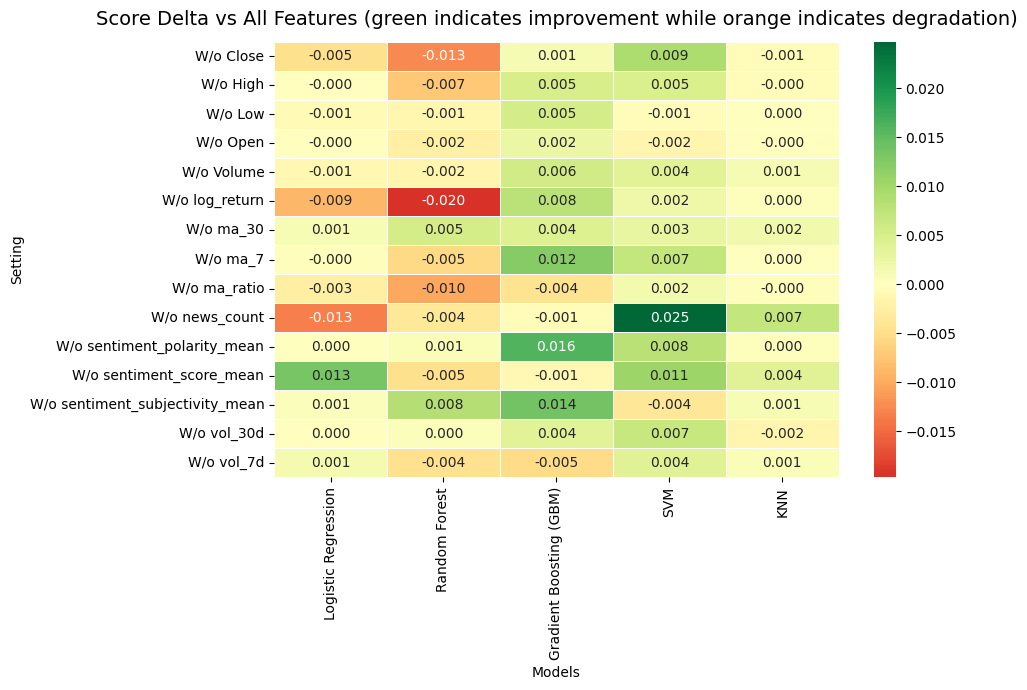

In [13]:
# Delta heatmap: Illustrate the impact of each feature to model performance
fig, ax = plt.subplots(figsize=(10, 7))

sns.heatmap(delta_df, annot=True, fmt=".3f",
            cmap='RdYlGn', center=0, ax=ax, linewidths=0.5)

ax.set_title('Score Delta vs All Features (green indicates improvement while orange indicates degradation)', fontsize=14, pad=12)
ax.set_xlabel('Models')
plt.tight_layout()

In general, the importance of each feature is vary across models.

- In logistic regression model, the model is most rely on `the number of news` and `log return` on the previous day to predict whether the close price of that token increases on the following day. Particularly, dropping `the number of news` and `log return` decrease the performance of model by `0.013` and `0.009` respectively. In contrast, mean sentiment score is considered as a noise to the model, when dropping it increase the model performance by 0.013. Dropping other features impact the model performance slightly 
- In the random forest model, `log return` is the most critical feature, removing it causes the largest performance drop of `0.020`. `Close price` and `ma ratio` also contribute meaningfully, with their removal degrading performance by `0.013` and `0.010` respectively. Removing `ma 30` and `sentiment score mean` slightly improves performance by `0.005`, suggesting they introduce minor noise. Other features have negligible impact.
- For GBM and SVM, we observed that dropping features primarily increase the performance. Especially, dropping `sentiment popularity`  and `subjectivity mean` improve the performance of GBM significantly, `0.016` and `0.014` respectively. At the same time, removing `the number of news` improve performance of SVM by `0.025`.
  - We attribute this observation to the fact that both GBM ann SVM is sensitive to redudant and irrelevant features. A smaller but more carefully selected subset of features would likely yield better and more stable performance than using all features together.
- For KNN, removing each features slightly impact the performance of the model

We then retrieve importance score from randomforest to compare and contrast


In [14]:
files = os.listdir(DATA_PATH)
task = BINARY_LABEL_COLUMN
seed_everything(INIT_SEED)

result_file_name = "random_forest_feat_importance_binary.csv"
result_path_file = os.path.join(RESULT_PATH,result_file_name)
if os.path.isfile(result_path_file) and not RE_RUN_EVERYTHING:
    random_forest_feat_importance_binary_df = pd.read_csv(result_path_file)
    print("INFO: LOADED existing results")

else:
    print("INFO: Re-computing results")
    random_forest_feat_importance_binary_df = feature_important_score_by_random_forest(files, task,RandomForestClassifier())
    random_forest_feat_importance_binary_df.to_csv(result_path_file,index=False)


random_forest_feat_importance_binary_df.head(32)


INFO: LOADED existing results


,feature,importance
0,log_return,0.087080
1,sentiment_subjectivity_mean,0.076759
2,sentiment_polarity_mean,0.074623
3,Volume,0.071608
4,vol_7d,0.070806
5,sentiment_score_mean,0.068155
6,ma_ratio,0.067019
7,Close,0.063548
8,vol_30d,0.063166
9,ma_7,0.062429


Text(0.5, 1.0, 'Importance score of each feature from Random tree')

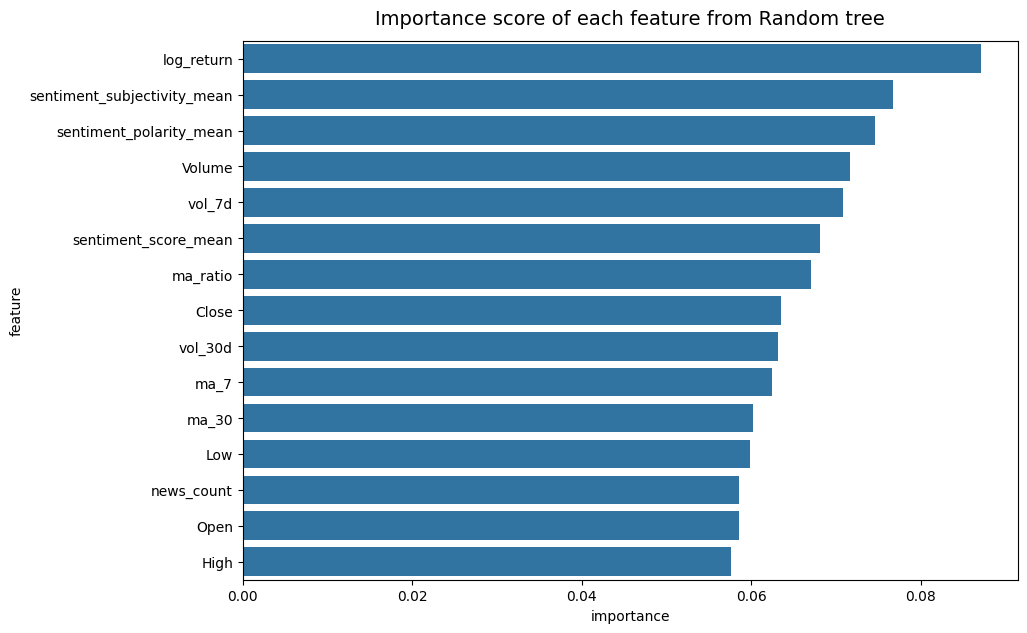

In [15]:
fig, ax = plt.subplots(figsize=(10, 7))
sns.barplot(data=random_forest_feat_importance_binary_df,x='importance',y='feature')
ax.set_title('Importance score of each feature from Random tree', fontsize=14, pad=12)

This result indicates `log return` is the most important feature for random forest, which align with observation that removing `log return` decreases the model performance the most. However, for many other features, their high importance score does not translate to a large performance drop when removed because correlated features can substitute for each other. For example, `Close`, `High`, `Low`, and `Open` are highly correlated, so when one is dropped the others compensate, making the individual drop experiment show little performance change despite each having moderate importance scores.

We attribute this observation due to the fact that: the importance score of random forest reflect how frequently and how effectively a feature is used during training to split nodes across all trees. However, it doesn't reflect how much the features contributes to the prediction on unseen data in test set, as droppring feature experiment reflects.

Next, we study the performance of each model accross 40 token networks 

<Axes: title={'center': 'Performance distribution of each model trained with all features'}, xlabel='Model', ylabel='Performance (AUC)'>

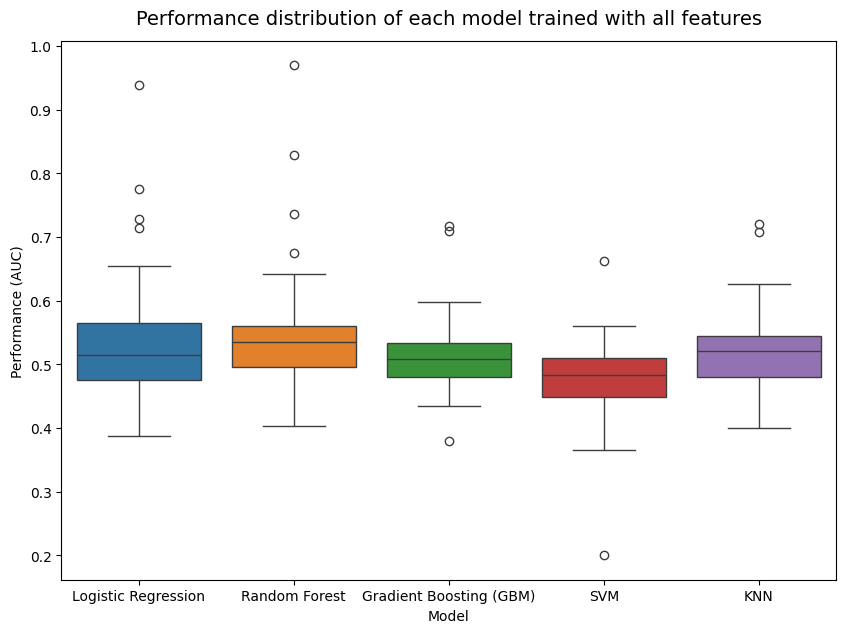

In [16]:
all_rows = []
for dataset in all_models_feat_importance_binary_df['Dataset'].unique().tolist():
    for model in model_cols:
        performance = all_models_feat_importance_binary_df[(all_models_feat_importance_binary_df['Dataset'] == dataset) &
                                                           (all_models_feat_importance_binary_df['Setting'] == 'All features')][model]
        all_rows.append({'Model': model, 'Dataset': dataset, 'Performance (AUC)': performance.values[0]})

tmp_df = pd.DataFrame(all_rows)

fig, ax = plt.subplots(figsize=(10, 7))
ax.set_title('Performance distribution of each model trained with all features', fontsize=14, pad=12)
sns.boxplot(data=tmp_df,y='Performance (AUC)',hue='Model',x='Model')

Across all five models, median AUC scores range from approximately `0.49` to `0.54`, hovering close to the random chance baseline of `0.50`, indicating that no model achieves strong predictive performance with the current feature set. Random Forest yields the highest median AUC but also the widest spread, suggesting inconsistent performance across different tokens. GBM is the most stable model with the tightest distribution, while SVM performs the worst, occasionally dropping as low as `0.20`. The high-end outliers present in all models suggest that predictability varies greatly across tokens, with some being more predictable than others. Overall, the results reflect the inherently noisy and unpredictable nature of cryptocurrency price movements.

In [25]:
filter_performance = tmp_df[tmp_df['Performance (AUC)'] >= 0.7]

display(filter_performance)

good_performance_datasets_list = list(filter_performance['Dataset'].unique())
performance_datasets_split = prepare_datasets(good_performance_datasets_list,ALL_FEAT_COLUMN, BINARY_LABEL_COLUMN)

# Compute label ratio of each dataset that has high model performance
rows = []
for train, val, test in performance_datasets_split:
    num_ones = test.y.sum().item()
    num_zeros = (test.y == 0).sum().item()
    total = len(test.y)

    rows.append({
        'Dataset': train.dataset_name,
        '1 (%)': f"{num_ones/total*100:.1f}%",
        '0 (%)': f"{num_zeros/total*100:.1f}%"
    })

df_label_balance = pd.DataFrame(rows)
display(df_label_balance)


,Model,Dataset,Performance (AUC)
145,Logistic Regression,pepe.csv,0.939394
146,Random Forest,pepe.csv,0.969697
149,KNN,pepe.csv,0.719697
170,Logistic Regression,shiba_inu.csv,0.714151
190,Logistic Regression,sui.csv,0.728758
191,Random Forest,sui.csv,0.828431
210,Logistic Regression,the_graph.csv,0.775000
212,Gradient Boosting (GBM),the_graph.csv,0.716667
214,KNN,the_graph.csv,0.708333
231,Random Forest,usd_coin.csv,0.735400


,Dataset,1 (%),0 (%)
0,pepe.csv,5.7%,94.3%
1,shiba_inu.csv,8.6%,91.4%
2,sui.csv,51.4%,48.6%
3,the_graph.csv,54.5%,45.5%
4,usd_coin.csv,45.7%,54.3%


Interestingly, two tokens, `pepe` and `shiba_inu`, have significant label imbalance, with the positive class (label 1) accounting for only 5.7% and 8.6% of samples respectively. This imbalance explains the unusually high AUC scores observed for these tokens, particularly `pepe`, where Logistic Regression and Random Forest achieve AUC scores of `0.939`and `0.970` respectively.

### 2.2 Regression setting

In the following section, we aim to answer the following research question:

> II. How do traditional machine learning models such as Linear Regression, Ridge, Lasso, Random Forest (regression version), GBM and SVR perform in predicting `close price` of a token in the following day (regression)? What is the importance of each feature contributing to the prediction?

In [28]:

from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning)
task = REGRESSION_LABEL_COLUMN
seed_everything(INIT_SEED)

result_file_name = "all_models_feat_importance_regression.csv"
result_path_file = os.path.join(RESULT_PATH,result_file_name)
if os.path.isfile(result_path_file) and not RE_RUN_EVERYTHING:
    all_models_feat_importance_regression_df = pd.read_csv(result_path_file)
    print("INFO: LOADED existing results")

else:
    print("INFO: Re-computing results")
    all_models_feat_importance_regression_df = drop_feature_experiment(files, task,regression_classfication_model_experience)
    all_models_feat_importance_regression_df.to_csv(result_path_file,index=False)


all_models_feat_importance_regression_df.head(60)



INFO: LOADED existing results


,Linear Regression,Ridge,Lasso,Random Forest,Gradient Boosting (GBM),SVR,Setting,Dataset
0,0.169489,0.177282,0.171393,0.181008,0.180376,0.533575,All features,aave.csv
1,0.283329,0.357584,1.614899,0.752668,0.767555,1.438937,All features,algorand.csv
2,0.182432,0.181959,0.212322,0.190484,0.178510,0.345639,All features,aptos.csv
3,0.179935,0.166002,0.245974,0.206464,0.216562,0.234709,All features,arbitrum.csv
4,0.229081,0.276157,0.214369,0.378532,0.484646,1.030327,All features,avalanche.csv
5,0.239455,0.361237,0.264389,0.537529,0.576486,1.537654,All features,axie_infinity.csv
6,0.128658,0.161138,0.130170,0.194331,0.184902,0.631840,All features,binance_coin.csv
7,0.125332,0.135818,0.125090,0.184696,0.202351,0.472529,All features,bitcoin.csv
8,0.153180,0.171616,0.149099,0.392569,0.284738,0.621855,All features,bitcoin_cash.csv
9,0.166153,0.209731,0.920776,0.207510,0.186407,0.778486,All features,cardano.csv


In [29]:
task = REGRESSION_LABEL_COLUMN
seed_everything(INIT_SEED)

result_file_name = "random_forest_feat_importance_regression.csv"
result_path_file = os.path.join(RESULT_PATH,result_file_name)
if os.path.isfile(result_path_file) and not RE_RUN_EVERYTHING:
    random_forest_feat_importance_regression_df = pd.read_csv(result_path_file)
    print("INFO: LOADED existing results")

else:
    print("INFO: Re-computing results")
    random_forest_feat_importance_regression_df = feature_important_score_by_random_forest(files, task,RandomForestRegressor())
    random_forest_feat_importance_regression_df.to_csv(result_path_file,index=False)


random_forest_feat_importance_regression_df.head(32)

INFO: LOADED existing results


,feature,importance
0,Close,0.476465
1,High,0.225673
2,Low,0.140717
3,Open,0.090383
4,ma_30,0.023700
5,ma_7,0.012485
6,vol_30d,0.006587
7,Volume,0.005272
8,log_return,0.005019
9,vol_7d,0.004157


## Time series baseline

In [ ]:
task = REGRESSION_LABEL_COLUMN
seed_everything(INIT_SEED)

result_file_name = "mape_arima_regression.csv"
result_path_file = os.path.join(RESULT_PATH,result_file_name)
if os.path.isfile(result_path_file) and not RE_RUN_EVERYTHING:
    arima_df = pd.read_csv(result_path_file)
    print("INFO: LOADED existing results")

else:
    print("INFO: Re-computing results")
    all_data_split = prepare_datasets(files, ALL_FEAT_COLUMN, task)

    all_rows_arima = []
    for train, val, test in tqdm(all_data_split):
        rmse = arima_baseline(train, test)
        all_rows_arima.append({'Dataset' : train.dataset_name, 'RMSE': rmse})
    
    arima_df = pd.DataFrame(all_rows_arima)
    arima_df.to_csv(result_path_file, index= False)


arima_df.head(32)

INFO: Re-computing results


100%|██████████| 49/49 [04:56<00:00,  6.05s/it]


,Dataset,RMSE
0,aave.csv,0.447640
1,algorand.csv,0.762574
2,aptos.csv,0.309518
3,arbitrum.csv,0.410068
4,avalanche.csv,0.695222
5,axie_infinity.csv,1.360145
6,binance_coin.csv,0.684181
7,bitcoin.csv,0.392519
8,bitcoin_cash.csv,0.848409
9,cardano.csv,0.613934


In [51]:
RESULT_PATH

'd:\\UoM1\\Fourth Year\\DATA 2010\\Project\\DATA2010\\data\\results'